In [1]:
import CubeGen.megaratools.megcubegen as mcube
import CubeGen.megaratools.megmapgen as mmap
import MapLines.tools.plot_tools as tol
from MapLines.tools.line_fit import line_fit,line_fit_single
import MapLines.tools.tools as tols
from astropy.io import fits
import numpy as np
import os.path as ptt
import matplotlib.pyplot as plt

## Ejemplo para generar un cubo del RSS

In [2]:
name=None
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC4-23ITP/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-R'
reduxL2=['obsid12'+vph]

In [3]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing Mrk1486


In [4]:
savefile=False
basenameM='megMap-NAME.fits'
if savefile:
    mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)
else:
    mapt,hdr=mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameM)

Processing Mrk1486


In [5]:
name=hdr['OBJECT']+'_'+vph
tols.sycall('mkdir -p outputs_fits')

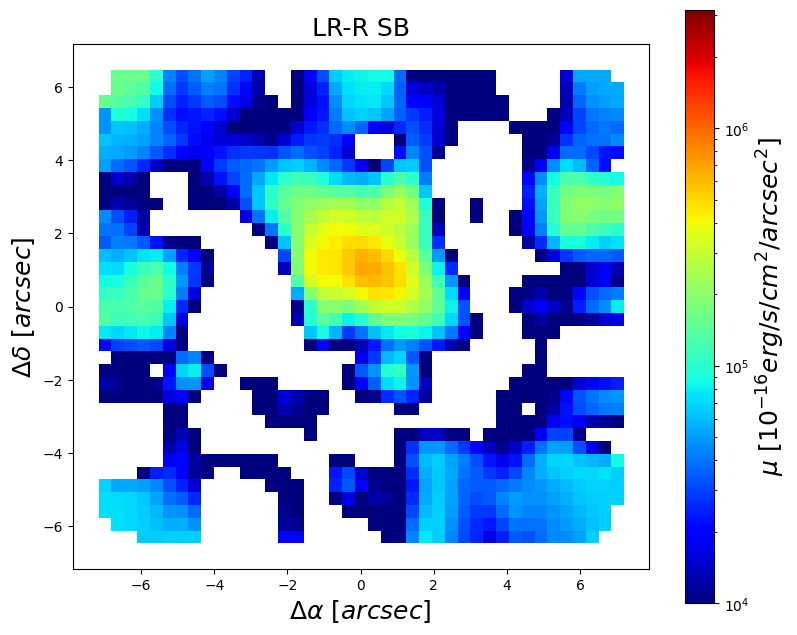

In [6]:
tol.get_plot(mapt,savef=True,pix=pix_s,name='outputs_fits/'+name,
             tit='\mu',title=vph+' SB',cbtr=True,maxmin=[10**4,10**6.5],ewp=False)

In [7]:
[data,hdr]=fits.getdata(out_path+basenameC.replace('NAME',name)+'.gz', 0, header=True)

In [8]:
zt=0.033829
nz,nx,ny=data.shape
crpix=hdr["CRPIX3"]
try:
    cdelt=hdr["CD3_3"]
except:
    cdelt=hdr["CDELT3"]
crval=hdr["CRVAL3"]
wave_f=crval+cdelt*(np.arange(nz)+1-crpix)
wave_f=wave_f/(1+zt)
ntw=np.where((wave_f > 6400) & (wave_f < 6600))[0]
flux=np.nanmean(data[ntw,:,:],axis=0)

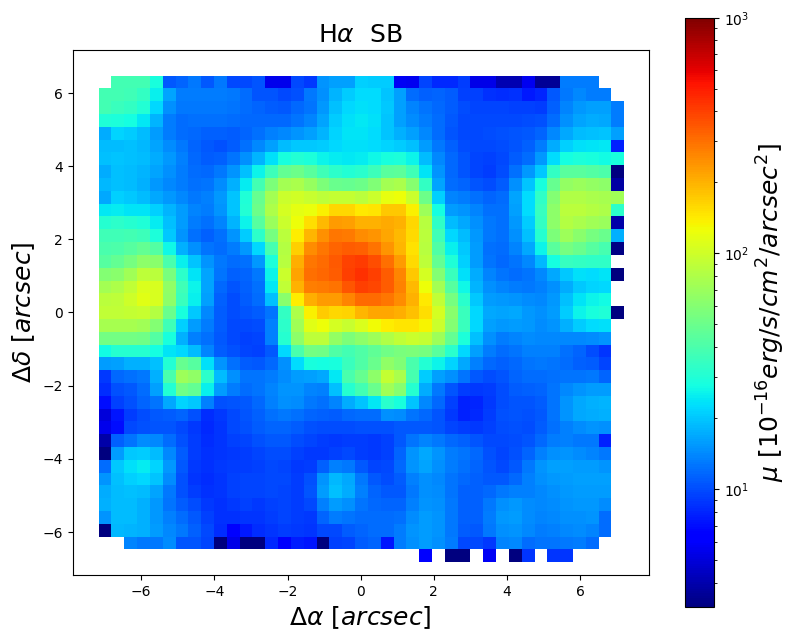

In [9]:
tol.get_plot(flux,savef=True,pix=pix_s,name='outputs_fits/'+name+'Ha',
             tit='\mu',title=r'H$\alpha$  SB',cbtr=True,maxmin=[10**0.5,10**3.0],ewp=False)

## Análisis de un cubo 

testing spaxel 22 , 21
Multiprocessing took 12.1 seconds


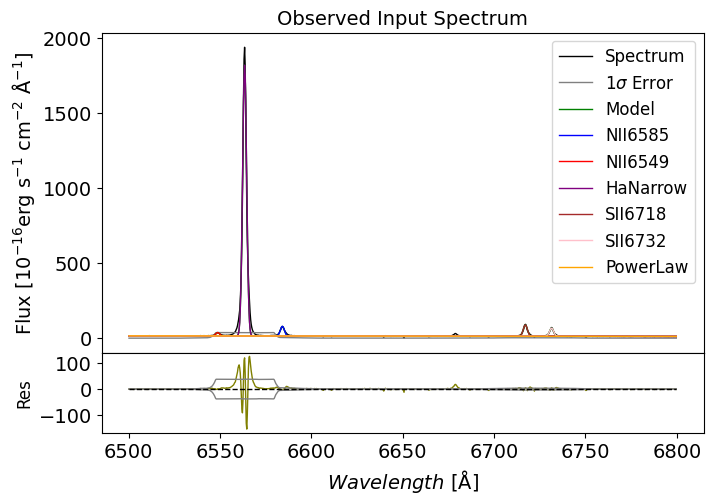

Ao0=64.36734569223611 dvo0=-54.54842491180115 fwhmo0=118.61739690526908 Ao2=1800.8291670427843 Ao3=75.06421900491043 Ao4=53.93108630345323 P1o=65.75991253312806 P2o=5.842557469983508


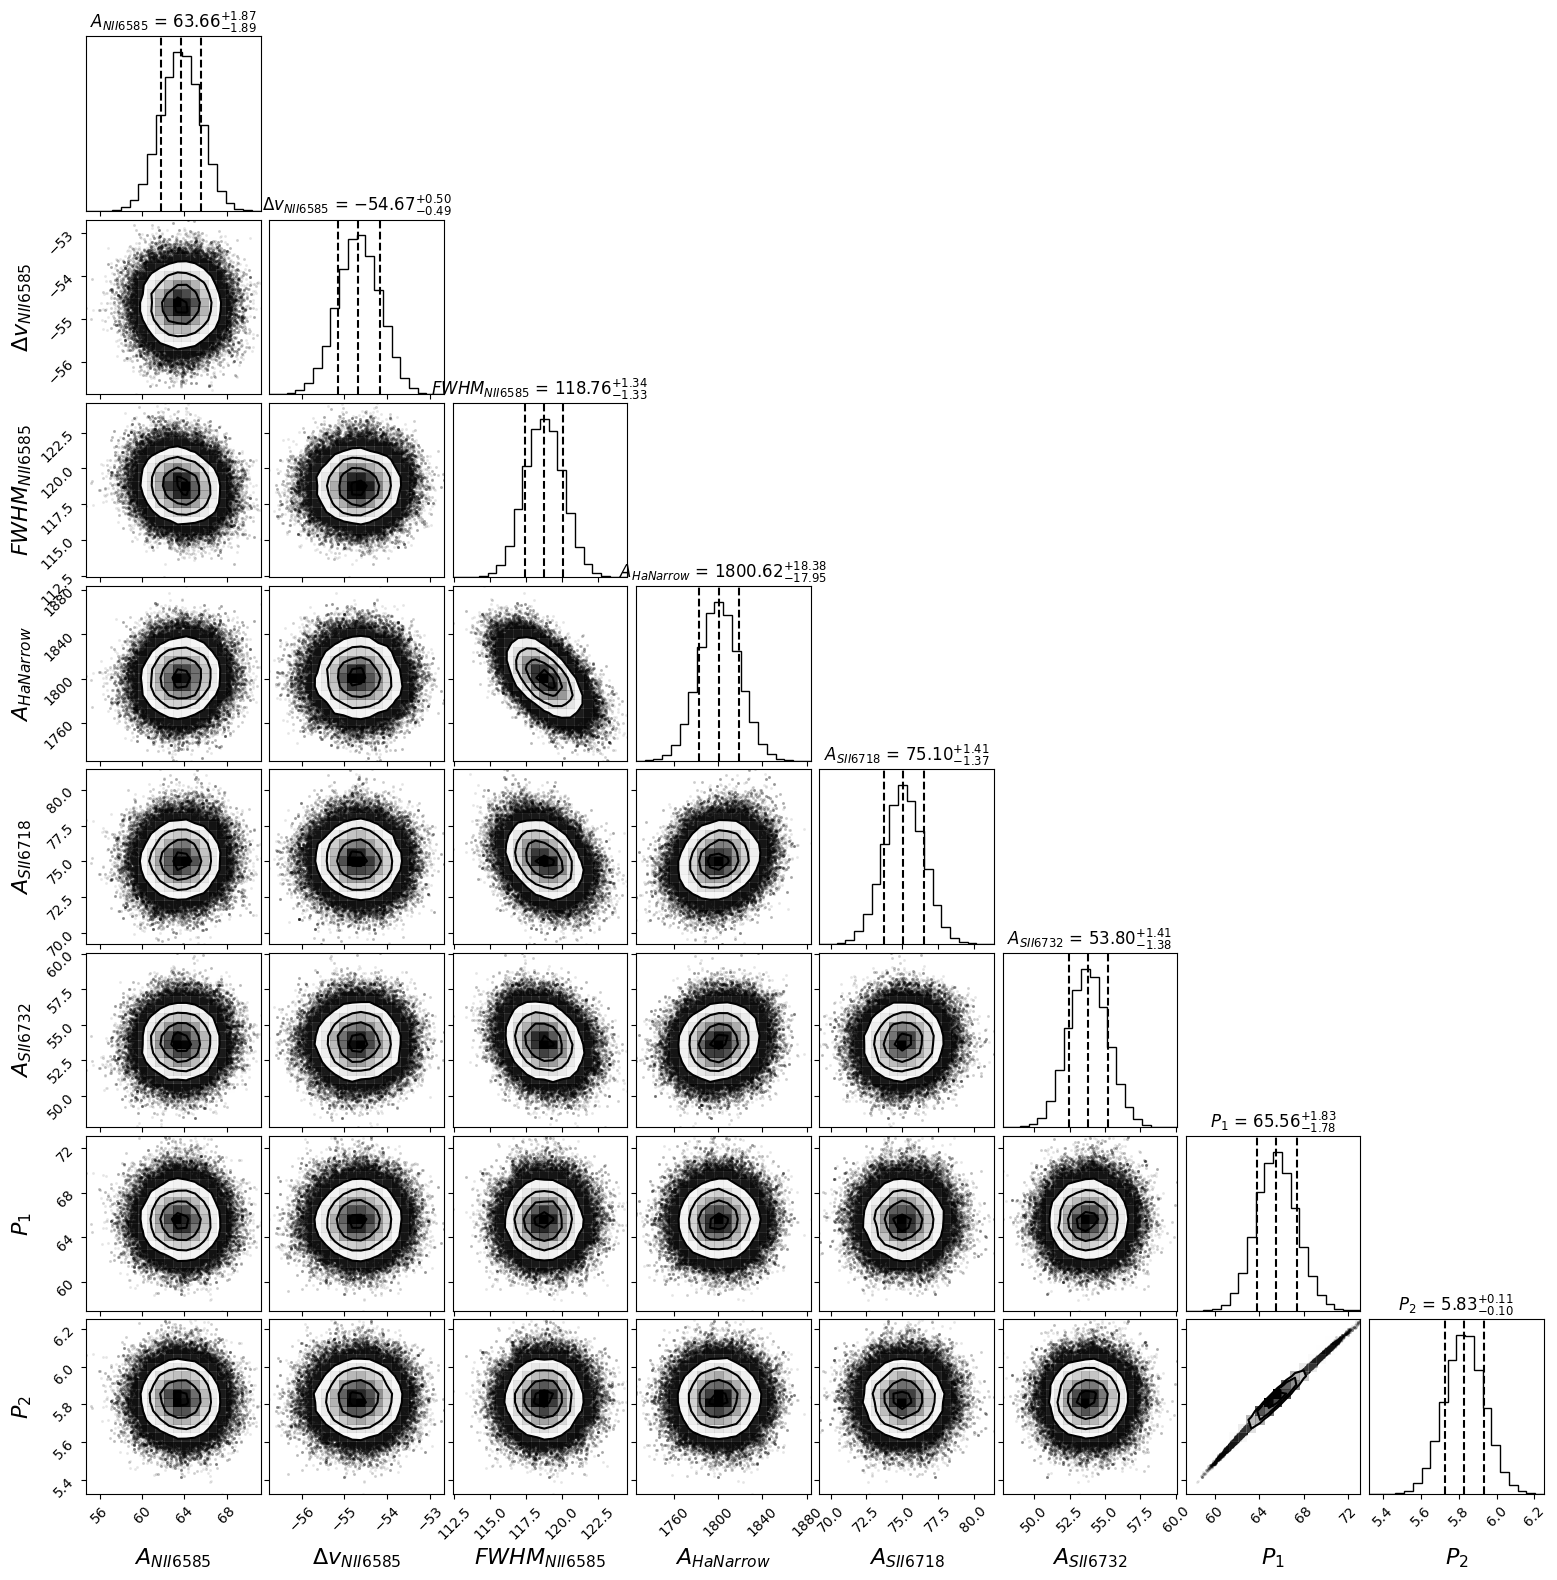

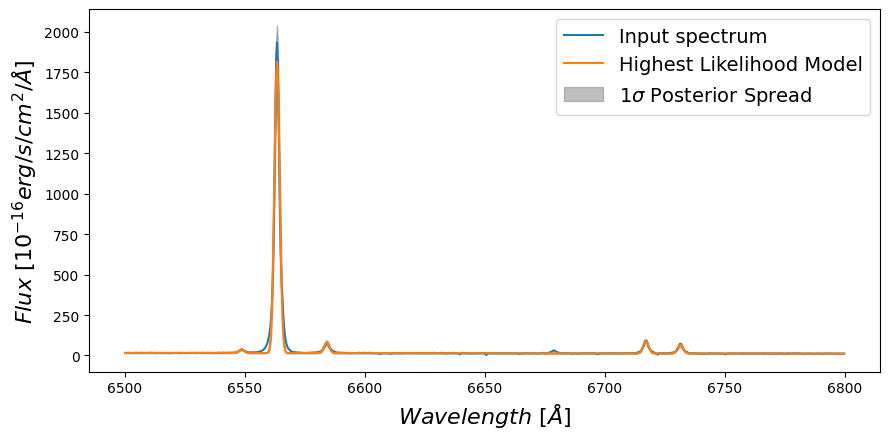

In [10]:
lA1= 6500.0 #initial wave vale, it overrides wave_range if not None
lA2= 6800.0 #final wave vale, it overrides wave_range if not None
wave_range= 'HaNIISII' #name of the spectral range, options are Hbeta, Halpha and None

name_out=name
test=True
sprogressd=False
cont=False
error_c=False
kskew=False
powlaw=True
res_norm=False
labplot=True
spe=150
dirt=out_path
dir_out='outputs_fits/'
ncpus=6
config_lines='config_lineHa.yml'
flux_f=1#/100.0 
it=22
jt=21
#zt=0.09785

if test:
    pgr_bar=False
    plot_f=True
else:
    plot_f=False
    if sprogressd:
        pgr_bar=False
    else:
        pgr_bar=True

if kskew:
    skew=True
    skl='_skew'
else:
    skew=False
    skl=''

file1=out_path+basenameC.replace('NAME',name)+'.gz'
file2=file1
file3=out_path+basenameC.replace('NAME','Mask')+'.gz'
if ptt.exists(dir_out) == False:
    tols.sycall('mkdir -p '+dir_out)
file_out=dir_out+'NAME_modelsV2'.replace('NAME',name_out)+wave_range+skl
file_out2=dir_out+'NAME_paramV2'.replace('NAME',name_out)+wave_range+skl
name_out2=name_out+wave_range+skl
line_fit(file1,file2,file3,file_out,file_out2,name_out2,z=zt,lA1=lA1,lA2=lA2,plot_f=plot_f,pgr_bar=pgr_bar,ncpu=ncpus,
         skew=skew,flux_f=flux_f,erft=0.75,cont=cont,test=test,error_c=error_c,i_t=it,j_t=jt,dir_out=dir_out,
         config_lines=config_lines,powlaw=powlaw,res_norm=res_norm,labplot=labplot,spe=spe,notebook=True)

In [11]:
name=None
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC4-23ITP/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-B'
reduxL2=['obsid12'+vph]

In [12]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing Mrk1486


In [13]:
savefile=False
basenameM='megMap-NAME.fits'
if savefile:
    mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)
else:
    mapt,hdr=mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameM)

Processing Mrk1486


In [14]:
name=hdr['OBJECT']+'_'+vph

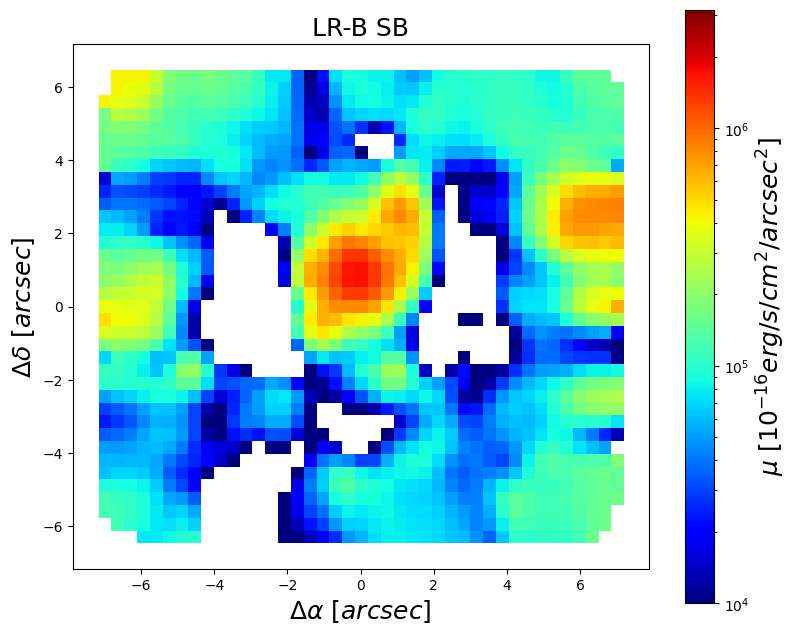

In [15]:
tol.get_plot(mapt,savef=True,pix=pix_s,name='outputs_fits/'+name,
             tit='\mu',title=vph+' SB',cbtr=True,maxmin=[10**4,10**6.5],ewp=False)

In [16]:
[data,hdr]=fits.getdata(out_path+basenameC.replace('NAME',name)+'.gz', 0, header=True)

In [17]:
zt=0.033829
nz,nx,ny=data.shape
crpix=hdr["CRPIX3"]
try:
    cdelt=hdr["CD3_3"]
except:
    cdelt=hdr["CDELT3"]
crval=hdr["CRVAL3"]
wave_f=crval+cdelt*(np.arange(nz)+1-crpix)
wave_f=wave_f/(1+zt)
ntw=np.where((wave_f > 5000) & (wave_f < 5015))[0]
flux=np.nanmean(data[ntw,:,:],axis=0)

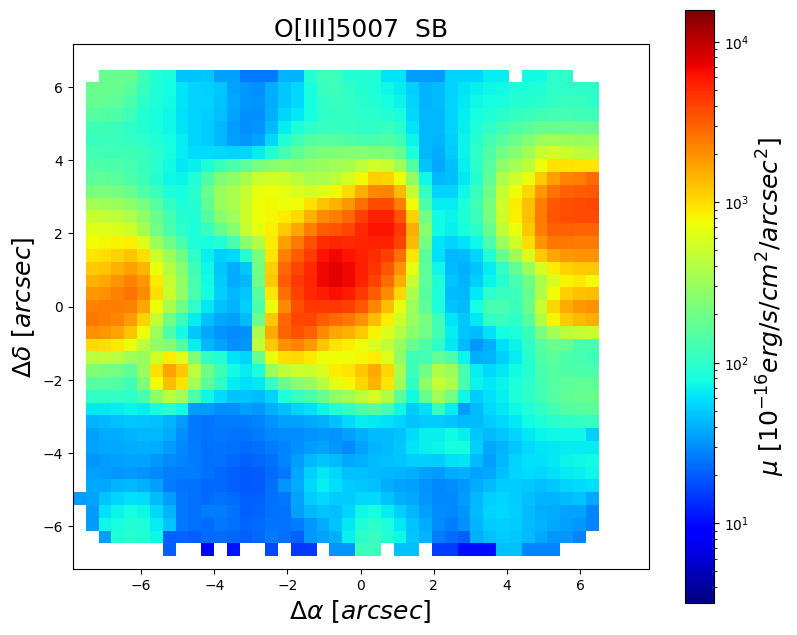

In [18]:
tol.get_plot(flux,savef=True,pix=pix_s,name='outputs_fits/'+name+'OIII',
             tit='\mu',title=r'O[III]5007  SB',cbtr=True,maxmin=[10**0.5,10**4.2],ewp=False)

testing spaxel 22 , 21
Multiprocessing took 10.3 seconds


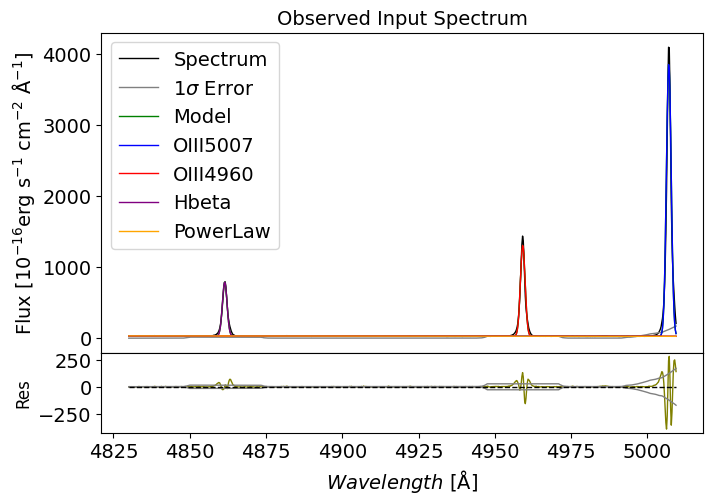

Ao0=3837.1754584386163 dvo0=-73.56470086366575 fwhmo0=110.2500256347263 Ao2=758.0666426318417 P1o=24.65893579896809 P2o=5.398365449238182


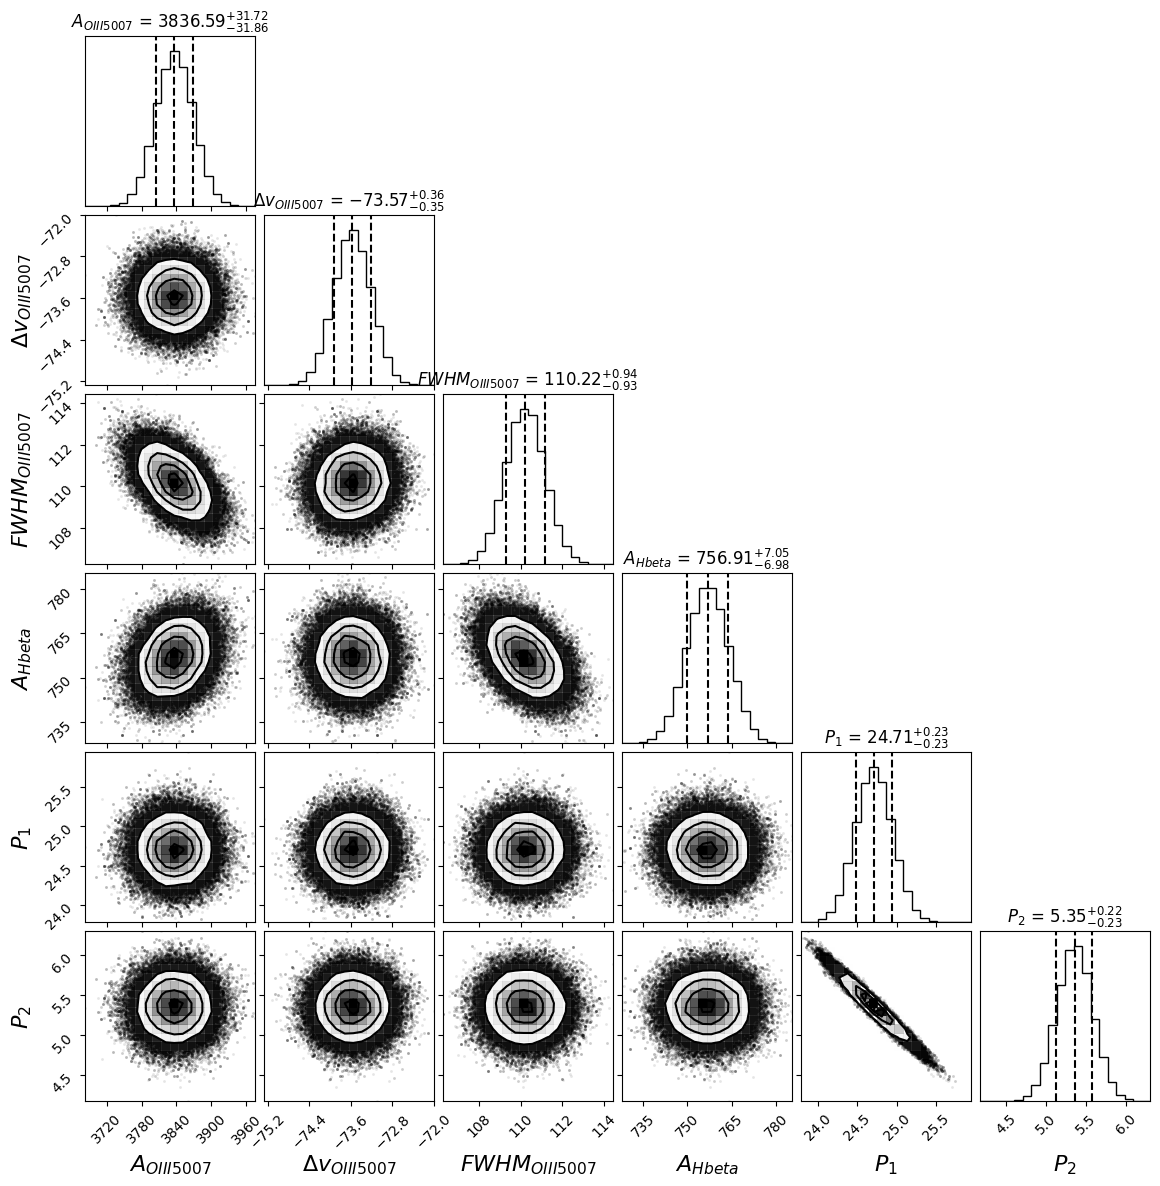

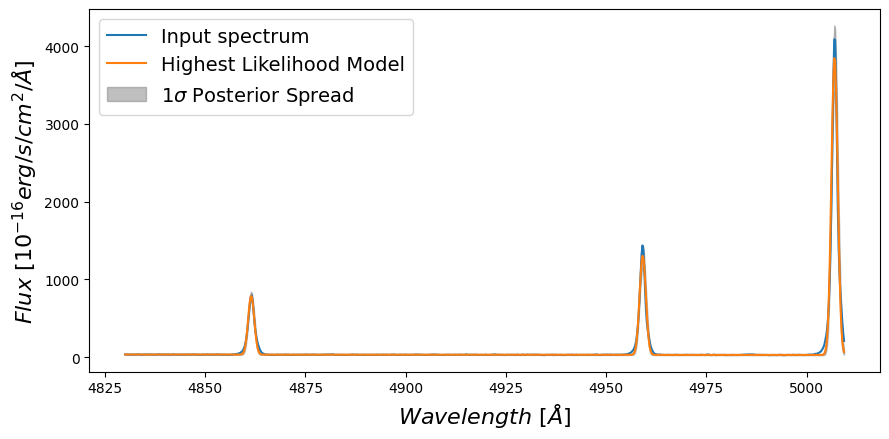

In [19]:
lA1= 4830.0 #initial wave vale, it overrides wave_range if not None
lA2= 5050.0 #final wave vale, it overrides wave_range if not None
wave_range= 'HbOIII' #name of the spectral range, options are Hbeta, Halpha and None

name_out=name
test=True
sprogressd=False
cont=False
error_c=False
kskew=False
powlaw=True
res_norm=False
labplot=True
spe=150
dirt=out_path
dir_out='outputs_fits/'
ncpus=6
config_lines='config_lineHb.yml'
flux_f=1#/400.0 
it=22
jt=21
#zt=0.09785

if test:
    pgr_bar=False
    plot_f=True
else:
    plot_f=False
    if sprogressd:
        pgr_bar=False
    else:
        pgr_bar=True

if kskew:
    skew=True
    skl='_skew'
else:
    skew=False
    skl=''

file1=out_path+basenameC.replace('NAME',name)+'.gz'
file2=file1
file3=out_path+basenameC.replace('NAME','Mask')+'.gz'
if ptt.exists(dir_out) == False:
    tols.sycall('mkdir -p '+dir_out)
file_out=dir_out+'NAME_modelsV2'.replace('NAME',name_out)+wave_range+skl
file_out2=dir_out+'NAME_paramV2'.replace('NAME',name_out)+wave_range+skl
name_out2=name_out+wave_range+skl
line_fit(file1,file2,file3,file_out,file_out2,name_out2,z=zt,lA1=lA1,lA2=lA2,plot_f=plot_f,pgr_bar=pgr_bar,ncpu=ncpus,
         skew=skew,flux_f=flux_f,erft=0.75,cont=cont,test=test,error_c=error_c,i_t=it,j_t=jt,dir_out=dir_out,
         config_lines=config_lines,powlaw=powlaw,res_norm=res_norm,labplot=labplot,spe=spe,notebook=True)

In [20]:
name=None
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC53-23B/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-R'
reduxL2=['obsid12'+vph]

In [21]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing J1440_LR-R


In [22]:
savefile=False
basenameM='megMap-NAME.fits'
if savefile:
    mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)
else:
    mapt,hdr=mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameM)

Processing J1440_LR-R


In [23]:
name=hdr['OBJECT']+'_'+vph

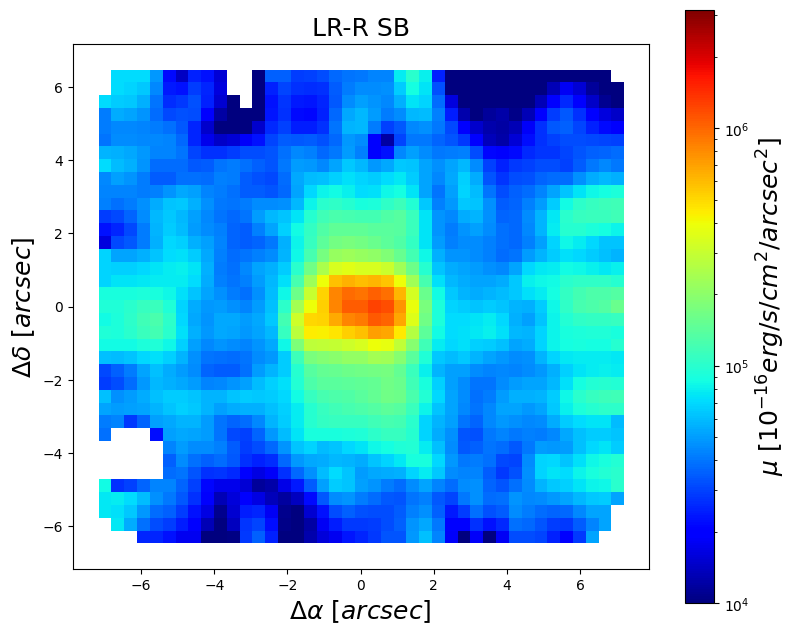

In [24]:
tol.get_plot(mapt,savef=True,pix=pix_s,name='outputs_fits/'+name,
             tit='\mu',title=vph+' SB',cbtr=True,maxmin=[10**4,10**6.5],ewp=False)

In [25]:
[data,hdr]=fits.getdata(out_path+basenameC.replace('NAME',name)+'.gz', 0, header=True)

In [26]:
zt=0.036889
nz,nx,ny=data.shape
crpix=hdr["CRPIX3"]
try:
    cdelt=hdr["CD3_3"]
except:
    cdelt=hdr["CDELT3"]
crval=hdr["CRVAL3"]
wave_f=crval+cdelt*(np.arange(nz)+1-crpix)
wave_f=wave_f/(1+zt)
ntw=np.where((wave_f > 6400) & (wave_f < 6600))[0]
flux=np.nanmean(data[ntw,:,:],axis=0)

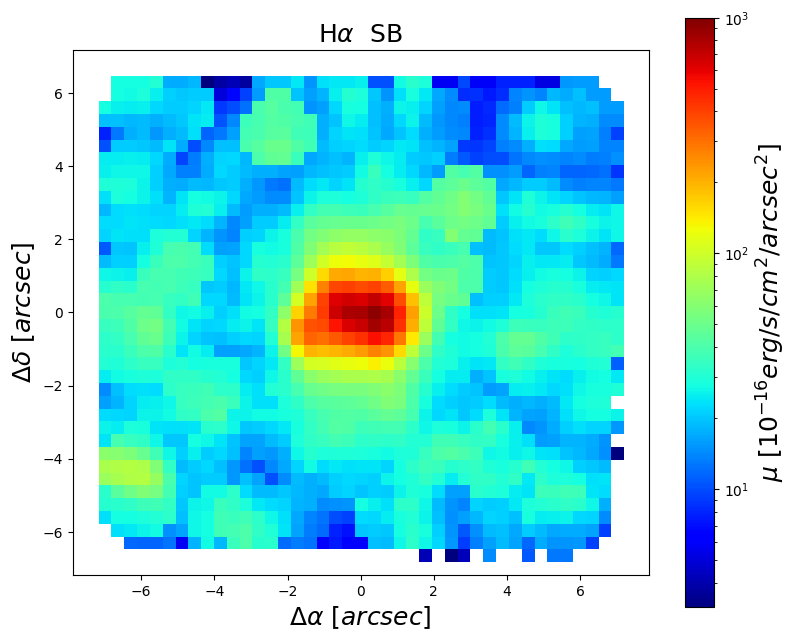

In [27]:
tol.get_plot(flux,savef=True,pix=pix_s,name='outputs_fits/'+name+'Ha',
             tit='\mu',title=r'H$\alpha$  SB',cbtr=True,maxmin=[10**0.5,10**3.0],ewp=False)

testing spaxel 19 , 21
Multiprocessing took 14.7 seconds


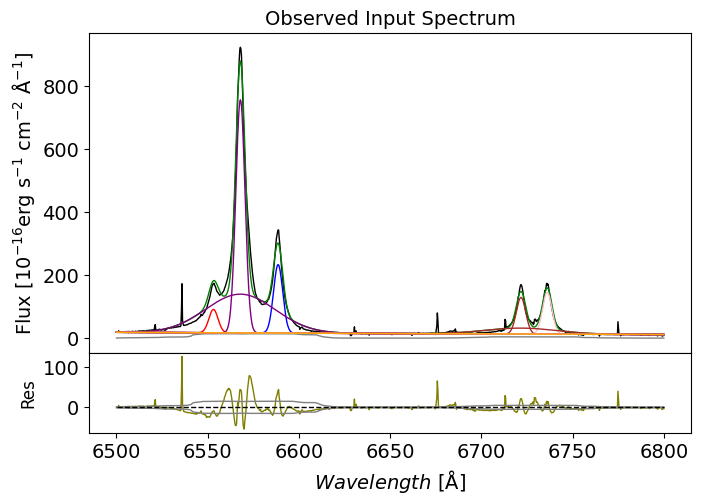

Ao0=217.24244364654308 dvo0=154.12671572855356 fwhmo0=269.67120304994165 Ao2=739.852036794173 Ao3=116.21111873099429 Ao4=132.45371208936845 Ao5=0.151252431203521 fwhmo5=2046.7043482846686 Ao7=122.9581572241449 Ao8=18.825924897976638 Ao9=0.08020270657143273 P1o=217.39527394373133 P2o=9.989785376094515


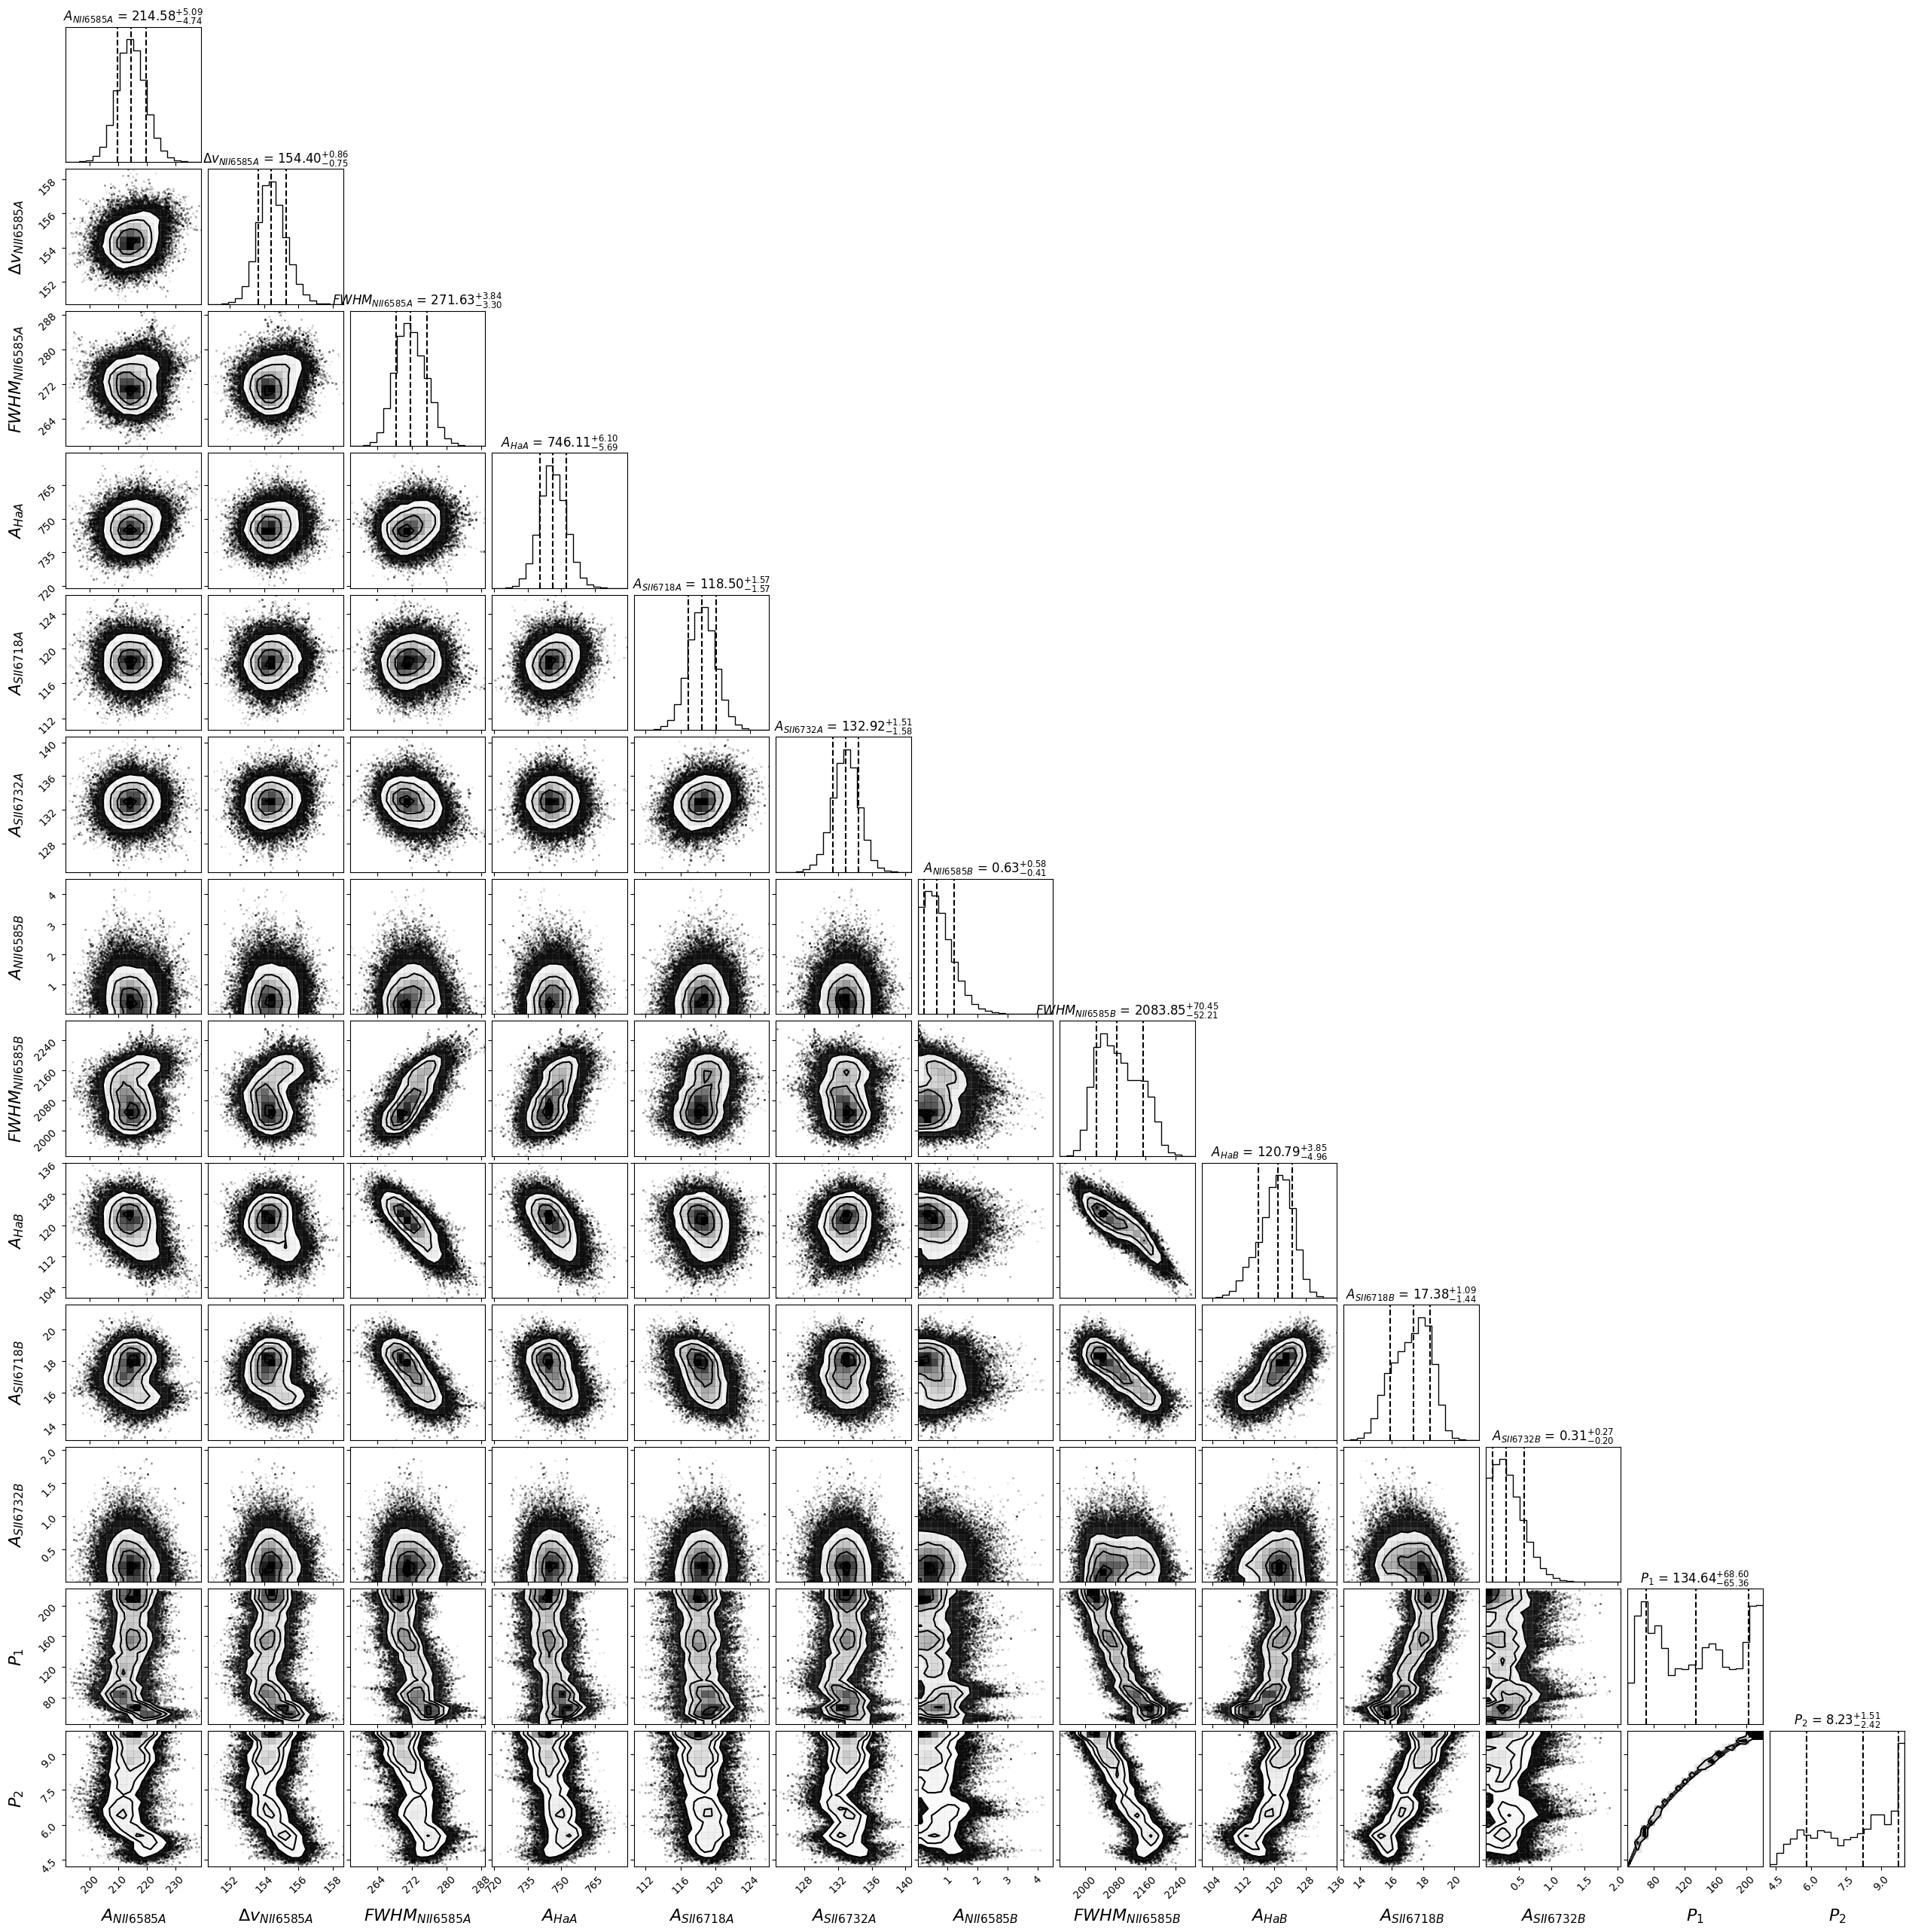

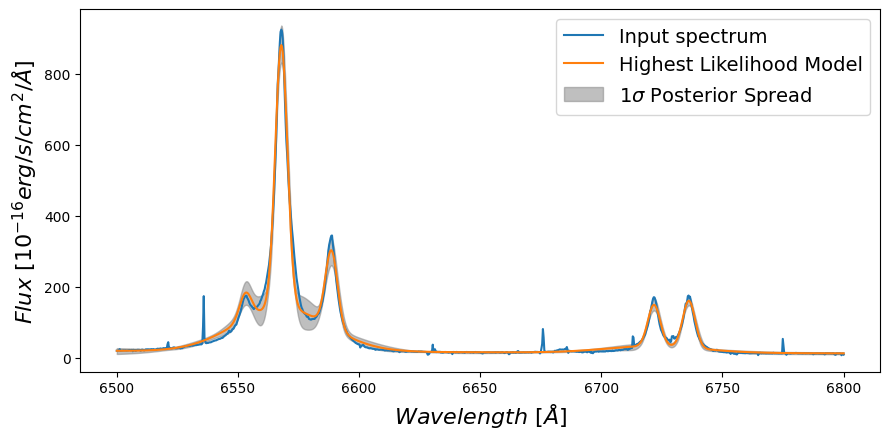

In [28]:
lA1= 6500.0 #6700.0#6250.0 #initial wave vale, it overrides wave_range if not None
lA2= 6800.0 #6620.0#6350.0#6800.0 #final wave vale, it overrides wave_range if not None
wave_range= 'HaNIISII' #name of the spectral range, options are Hbeta, Halpha and None

name_out=name
test=True
sprogressd=False
cont=False
error_c=False
kskew=False
powlaw=True
res_norm=False
labplot=False
spe=250
dirt=out_path
dir_out='outputs_fits/'
ncpus=6
config_lines='config_lineHaC.yml'
flux_f=1#/100.0 
it=19
jt=21
#zt=0.09785

if test:
    pgr_bar=False
    plot_f=True
else:
    plot_f=False
    if sprogressd:
        pgr_bar=False
    else:
        pgr_bar=True

if kskew:
    skew=True
    skl='_skew'
else:
    skew=False
    skl=''

file1=out_path+basenameC.replace('NAME',name)+'.gz'
file2=file1
file3=out_path+basenameC.replace('NAME','Mask')+'.gz'
if ptt.exists(dir_out) == False:
    tols.sycall('mkdir -p '+dir_out)
file_out=dir_out+'NAME_modelsV2'.replace('NAME',name_out)+wave_range+skl
file_out2=dir_out+'NAME_paramV2'.replace('NAME',name_out)+wave_range+skl
name_out2=name_out+wave_range+skl
line_fit(file1,file2,file3,file_out,file_out2,name_out2,z=zt,lA1=lA1,lA2=lA2,plot_f=plot_f,pgr_bar=pgr_bar,ncpu=ncpus,
         skew=skew,flux_f=flux_f,erft=0.75,cont=cont,test=test,error_c=error_c,i_t=it,j_t=jt,dir_out=dir_out,outflow=False,
         config_lines=config_lines,powlaw=powlaw,res_norm=res_norm,labplot=labplot,spe=spe,notebook=True)

## Ejemplo de staking

In [29]:
name='NGC6505_coadd'
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC06-24ADDT_OB04/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-V'
reduxL2=['obsid12'+vph,'obsid13'+vph]

In [30]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing NGC6505_center
Processing NGC6505_center


In [31]:
savefile=False
basenameM='megMap-NAME.fits'
if savefile:
    mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)
else:
    mapt,hdr=mmap.meggen_map(reduxL2,savefile=savefile,nameF=None,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,
        sigm_s=sigm_s,alph_s=alph_s,out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameM)

Processing NGC6505_center
Processing NGC6505_center


In [32]:
name=hdr['OBJECT']+'_'+vph

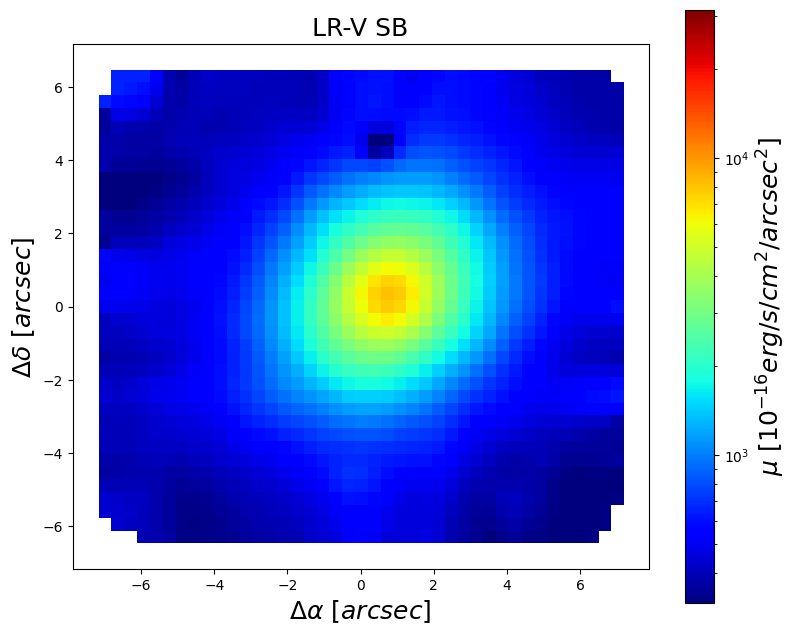

In [33]:
tol.get_plot(mapt,savef=True,pix=pix_s,name='outputs_fits/'+name,
             tit='\mu',title=vph+' SB',cbtr=True,maxmin=[10**2.5,10**4.5],ewp=False)

In [35]:
name='NGC6505_coadd'
[data0,hdr0]=fits.getdata(out_path+basenameC.replace('NAME',name+'_'+vph)+'.gz', 0, header=True)

In [36]:
name='NGC6505_single'
flu16=True
fac_sizeX=1.1
fac_sizeY=1.1
pix_s=0.35
sigm_s=0.35
alph_s=2.0
redux_dir='redux/GTC06-24ADDT_OB04/'
out_path='ifus/'
basenameC='megCube-NAME.fits'
vph='LR-V'
reduxL2=['obsid12'+vph]

In [37]:
mcube.megmap_ifu(reduxL2,nameF=name,flu16=flu16,fac_sizeX=fac_sizeX,fac_sizeY=fac_sizeY,pix_s=pix_s,sigm_s=sigm_s,alph_s=alph_s,
        out_path=out_path,redux_dir=redux_dir,vph=vph,basenameC=basenameC)

Processing NGC6505_center


In [38]:
name='NGC6505_single'
[data1,hdr1]=fits.getdata(out_path+basenameC.replace('NAME',name+'_'+vph)+'.gz', 0, header=True)

In [39]:
nz,nx,ny=data0.shape
crpix=hdr0["CRPIX3"]
try:
    cdelt=hdr0["CD3_3"]
except:
    cdelt=hdr0["CDELT3"]
crval=hdr0["CRVAL3"]
wave0=crval+cdelt*(np.arange(nz)+1-crpix)
flux0=np.nansum(data0,axis=1)
flux0=np.nansum(flux0,axis=1)

In [40]:
nz,nx,ny=data1.shape
crpix=hdr1["CRPIX3"]
try:
    cdelt=hdr1["CD3_3"]
except:
    cdelt=hdr1["CDELT3"]
crval=hdr1["CRVAL3"]
wave1=crval+cdelt*(np.arange(nz)+1-crpix)
flux1=np.nansum(data1,axis=1)
flux1=np.nansum(flux1,axis=1)

(30.0, 60.0)

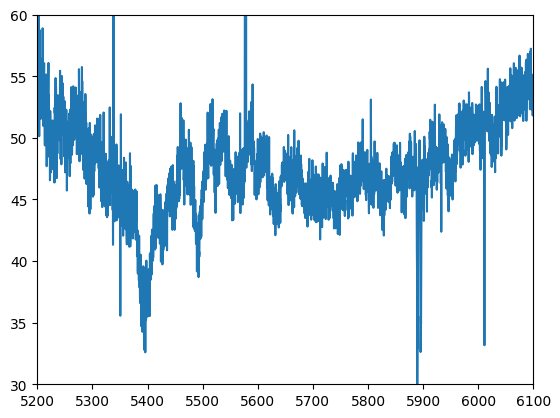

In [41]:
plt.plot(wave1,flux1)
plt.xlim(5200,6100)
plt.ylim(30,60)

(30.0, 60.0)

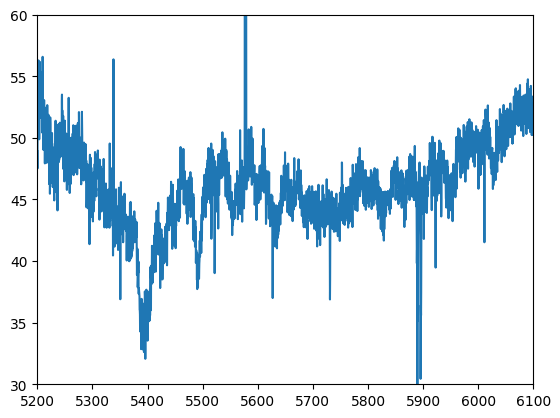

In [42]:
plt.plot(wave0,flux0)
plt.xlim(5200,6100)
plt.ylim(30,60)